<a href="https://colab.research.google.com/github/rawanahmedashraf-blip/hidden-gaps-students-opportunities/blob/main/notebooks/student_data_phase0_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

عدد الوظائف بعد فلترة الخبرة (Entry/Junior): 235
توزيع سنوات الخبرة في العينة:
experience year
notspecified    109
junior(1-3)      82
entry(0-1)       44
Name: count, dtype: int64

--- نسب المهارات المطلوبة (Market Demand %) ---
communication_mentioned     93.2
any_viz_required            80.9
teamwork_mentioned          80.4
statistics_required         55.7
sql_required                54.9
excel_required              48.5
python_required             40.4
domain_knowledge            40.0
ml_required                 34.0
cloud_tools                 12.8
certifications_preferred     6.4
dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

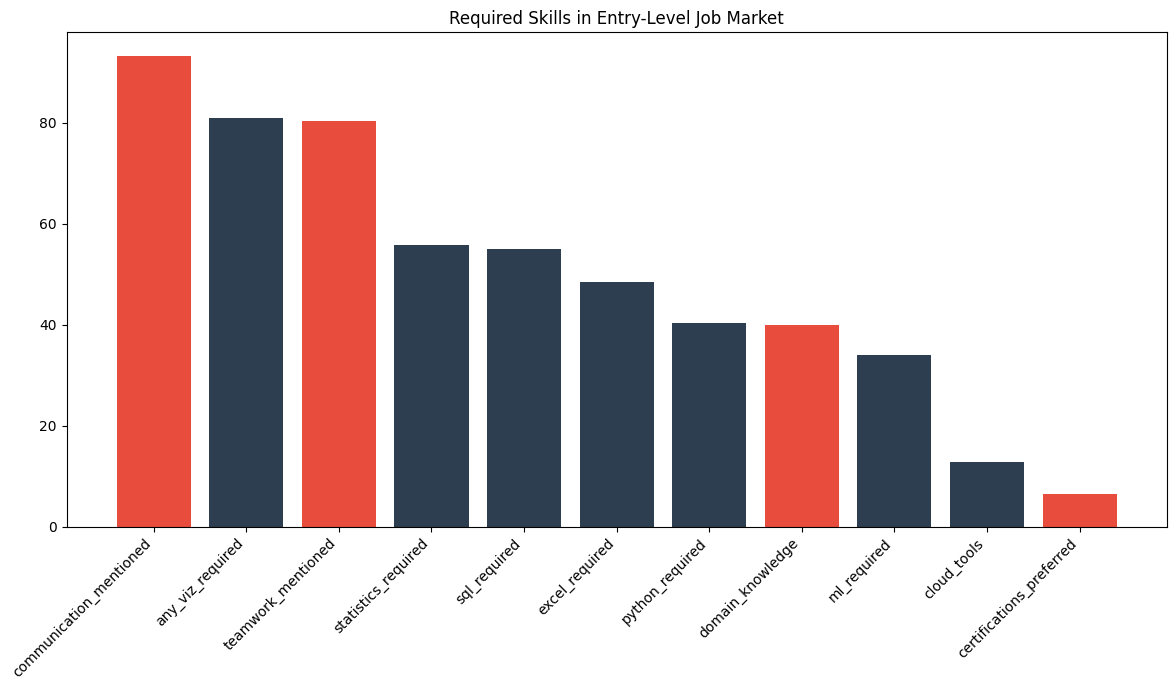

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

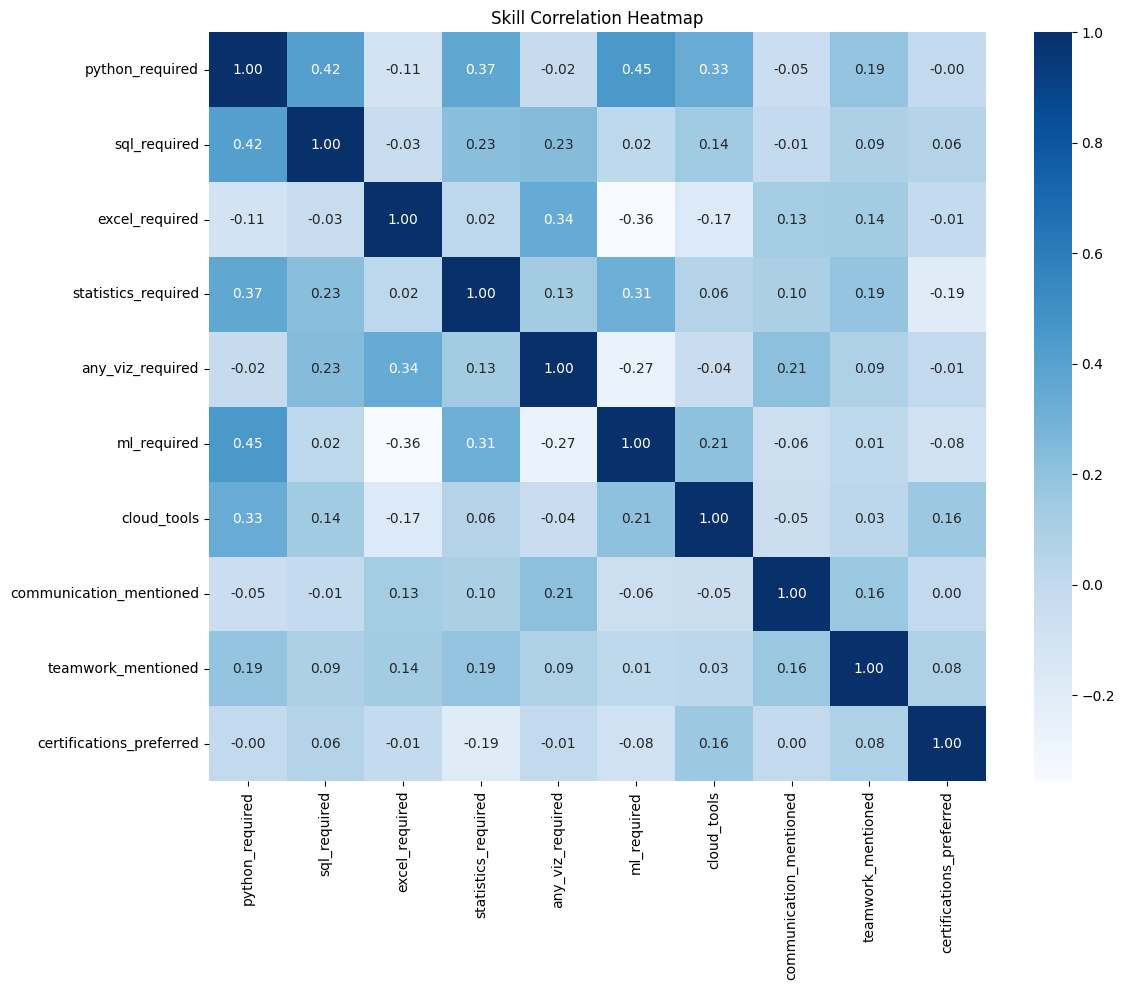

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

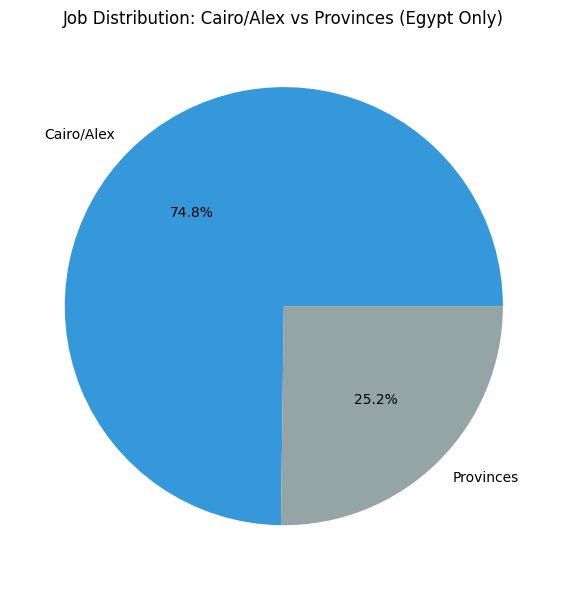

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

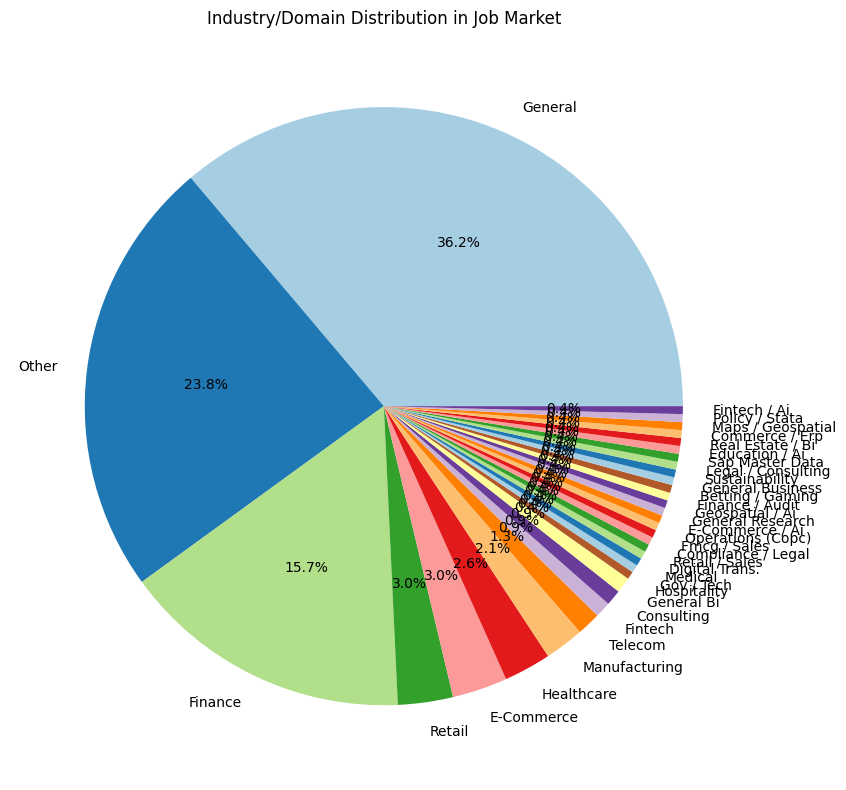

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅اشطر تيم Gaplens في الدنيا خلصوا phase 0🥳🥳🥳.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 1. قراءة البيانات
df = pd.read_excel('/content/4_5999111251337157865.xlsx')

# 2. إزالة التكرارات (لضمان عدم تكرار نفس الوظيفة من مصادر مختلفة)
df = df.drop_duplicates(subset=['job_title', 'company_name'])

# 3. توحيد النصوص (Text Normalization)
text_cols = ['job_title', 'company_name', 'city', 'country', 'experience year', 'remote_option', 'degree_level']
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()

# معالجة عمود المجال (Domain) وتوحيده كـ Title Case للعرض في الرسم البياني
if 'domain_knowledge' in df.columns:
    df['domain_knowledge'] = df['domain_knowledge'].astype(str).str.strip().str.title()
    df['domain_knowledge'] = df['domain_knowledge'].replace(['Nan', 'None', ''], 'General')

# 4. تنظيف عمود الخبرة + فلترة Entry / Junior (التعديل المطلوب: عرض العدد)
df['experience year'] = (
    df['experience year']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace('–', '-', regex=False)
    .str.replace(' ', '', regex=False)
)

# الفلترة لضمان مطابقة الفئة المستهدفة لحديثي التخرج
entry_df = df[df['experience year'].isin(['entry(0-1)', 'junior(1-3)', 'notspecified'])].copy()

print("="*40)
print(f"عدد الوظائف بعد فلترة الخبرة (Entry/Junior): {len(entry_df)}")
print("توزيع سنوات الخبرة في العينة:")
print(entry_df['experience year'].value_counts())
print("="*40)

# 5. التوحيد الجغرافي (Categorization)
def categorize_job_location(row):
    country = str(row.get('country', '')).lower()
    city = str(row.get('city', '')).lower()
    if 'egypt' not in country and 'nan' not in country:
        return 'Gulf/Other'
    cairo_alex = ['cairo', 'giza', 'alex', 'alexandria', 'القاهرة', 'الجيزة', 'الإسكندرية']
    return 'Cairo/Alex' if any(c in city for c in cairo_alex) else 'Provinces'

entry_df['region_category'] = entry_df.apply(categorize_job_location, axis=1)

# 6. معالجة مهارات العرض (Logical OR)
entry_df['any_viz_required'] = (
    entry_df['tableau_required'].fillna(False).astype(bool) |
    entry_df['powerbi_required'].fillna(False).astype(bool) |
    entry_df['viz_general'].fillna(False).astype(bool)
)

# 7. قائمة المهارات التقنية والناعمة
skill_cols = [
    'python_required', 'sql_required', 'excel_required',
    'statistics_required', 'any_viz_required', 'ml_required', 'cloud_tools',
    'communication_mentioned', 'teamwork_mentioned',
    'certifications_preferred'
]

# تحويل القيم إلى Boolean لضمان دقة الحسابات الإحصائية
for col in skill_cols:
    if col in entry_df.columns:
        entry_df[col] = entry_df[col].fillna(False).astype(bool)

# 8. حساب نسب الطلب في السوق (Market Demand %)
market_demand = (entry_df[skill_cols].mean() * 100).round(1)

# حساب مهارة المجال (استبعاد الفئات العامة لحساب التخصص المطلق)
domain_specific_count = sum(~entry_df['domain_knowledge'].isin(['General', 'Other', 'Blanks']))
market_demand['domain_knowledge'] = round((domain_specific_count / len(entry_df)) * 100, 1)

market_demand = market_demand.sort_values(ascending=False)
print("\n--- نسب المهارات المطلوبة (Market Demand %) ---")
print(market_demand)

# ---------------------------------------------------------
# 9. استخراج الملفات والرسوم البيانية (المخرجات النهائية)
# ---------------------------------------------------------

# أ) حفظ ملف نسب الطلب للمرحلة القادمة (Gap Analysis)
demand_df = pd.DataFrame({'Skill': market_demand.index, 'Market Demand %': market_demand.values})
demand_df.to_csv('job_market_demand_COMPLETE.csv', index=False)
files.download('job_market_demand_COMPLETE.csv')

# ب) مخطط المهارات المطلوبة (Bar Chart)
plt.figure(figsize=(12, 7))
soft_skills = ['communication_mentioned', 'teamwork_mentioned', 'domain_knowledge', 'certifications_preferred']
colors = ['#e74c3c' if skill in soft_skills else '#2c3e50' for skill in market_demand.index]
plt.bar(market_demand.index, market_demand.values, color=colors)
plt.title("Required Skills in Entry-Level Job Market")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('market_demand.png', dpi=300)
plt.show()
files.download('market_demand.png')

# ج) خريطة الارتباط بين المهارات (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(entry_df[skill_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Skill Correlation Heatmap")
plt.tight_layout()
plt.savefig('market_correlation.png', dpi=300)
plt.show()
files.download('market_correlation.png')

# د) التوزيع الجغرافي داخل مصر فقط (Egypt Only Analysis)
# فلترة البيانات لاستبعاد الخليج في هذه الرسمة تحديداً
egypt_only_df = entry_df[entry_df['region_category'] != 'Gulf/Other']
geo_dist_egypt = egypt_only_df['region_category'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(geo_dist_egypt.values, labels=geo_dist_egypt.index, autopct='%1.1f%%', colors=['#3498db', '#95a5a6'])
plt.title("Job Distribution: Cairo/Alex vs Provinces (Egypt Only)")
plt.tight_layout()
plt.savefig('geographic_distribution_jobs_egypt.png', dpi=300)
plt.show()
files.download('geographic_distribution_jobs_egypt.png')

# هـ) توزيع مجالات العمل (Domain Distribution)
plt.figure(figsize=(10, 8))
domain_dist = entry_df['domain_knowledge'].value_counts()
domain_dist = domain_dist[domain_dist > 0]
plt.pie(domain_dist.values, labels=domain_dist.index, autopct='%1.1f%%', colors=sns.color_palette("Paired"))
plt.title("Industry/Domain Distribution in Job Market")
plt.tight_layout()
plt.savefig('domain_distribution.png', dpi=300)
plt.show()
files.download('domain_distribution.png')

# 10. التصدير النهائي للداتا المتكاملة
entry_df.to_csv('clean_jobs_data_filtered_v2.csv', index=False)
files.download('clean_jobs_data_filtered_v2.csv')

print("\n✅اشطر تيم Gaplens في الدنيا خلصوا phase 0🥳🥳🥳.")